In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_interval = pd.read_csv('./data/C - Interval.csv', index_col=0)
df_interval.head(10)

,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,April,1,00:00:00,1.0000,72.0,0.0,0.0,283.29
1,April,1,00:30:00,1.0000,56.0,0.0,0.0,293.89
2,April,1,01:00:00,1.0000,31.0,0.0,0.0,323.45
3,April,1,01:30:00,1.0000,34.0,0.0,0.0,247.38
4,April,1,02:00:00,1.0000,16.0,0.0,0.0,282.69
5,April,1,02:30:00,0.9286,14.0,0.0,0.0,293.57
6,April,1,03:00:00,1.0000,11.0,0.0,0.0,198.64
7,April,1,03:30:00,1.0000,13.0,0.0,0.0,272.77
8,April,1,04:00:00,1.0000,8.0,0.0,0.0,467.38
9,April,1,04:30:00,1.0000,12.0,0.0,0.0,122.75


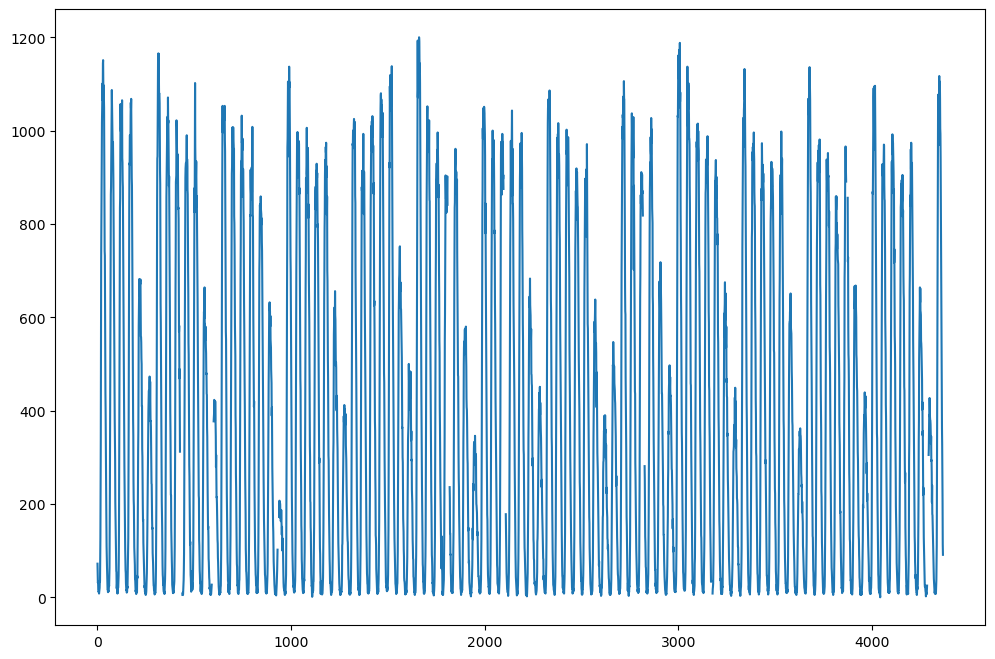

In [4]:
plt.figure(figsize=(12, 8))
plt.plot(df_interval['Call Volume'])
plt.show()

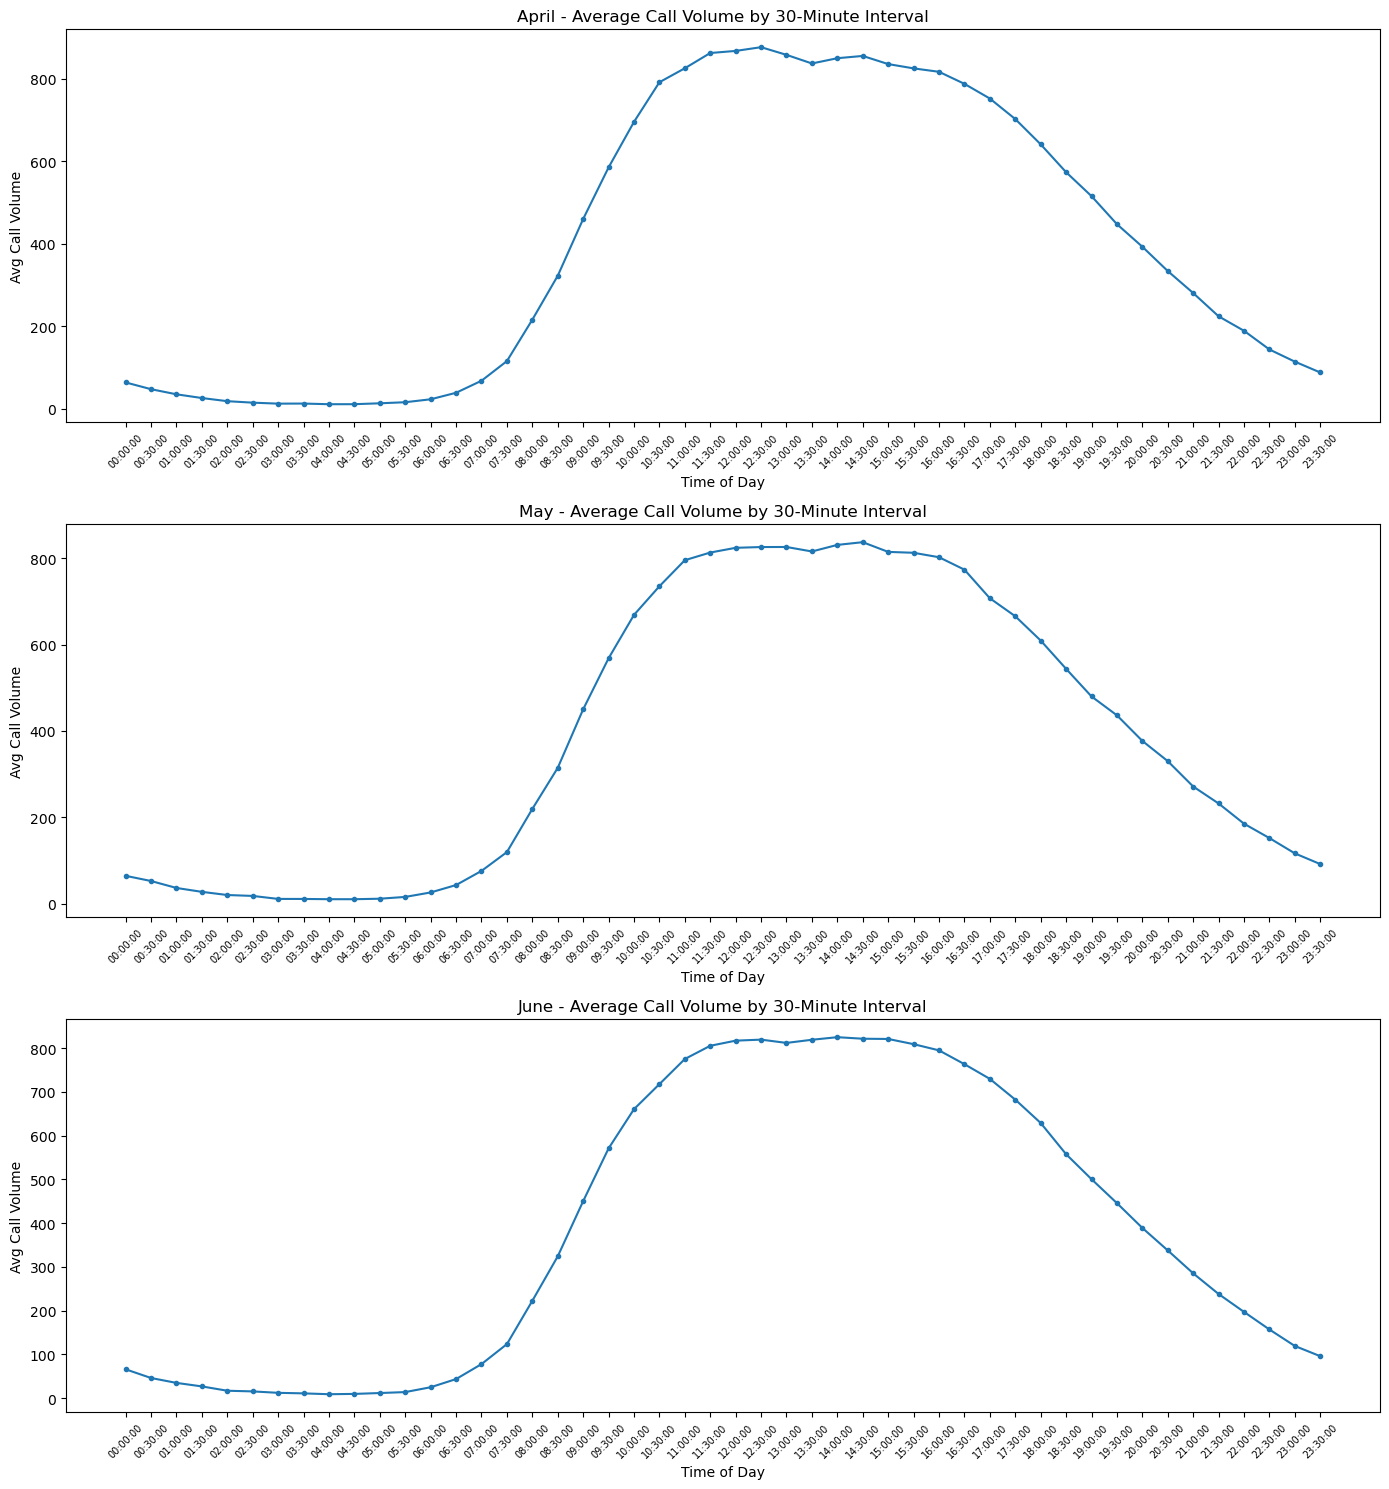

In [5]:
months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    interval_volume = df_month.groupby('Interval')['Call Volume'].mean().reset_index()
    
    ax.plot(interval_volume['Interval'], interval_volume['Call Volume'], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(f'{month} - Average Call Volume by 30-Minute Interval')
    ax.set_xlabel('Time of Day')
    ax.set_ylabel('Avg Call Volume')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

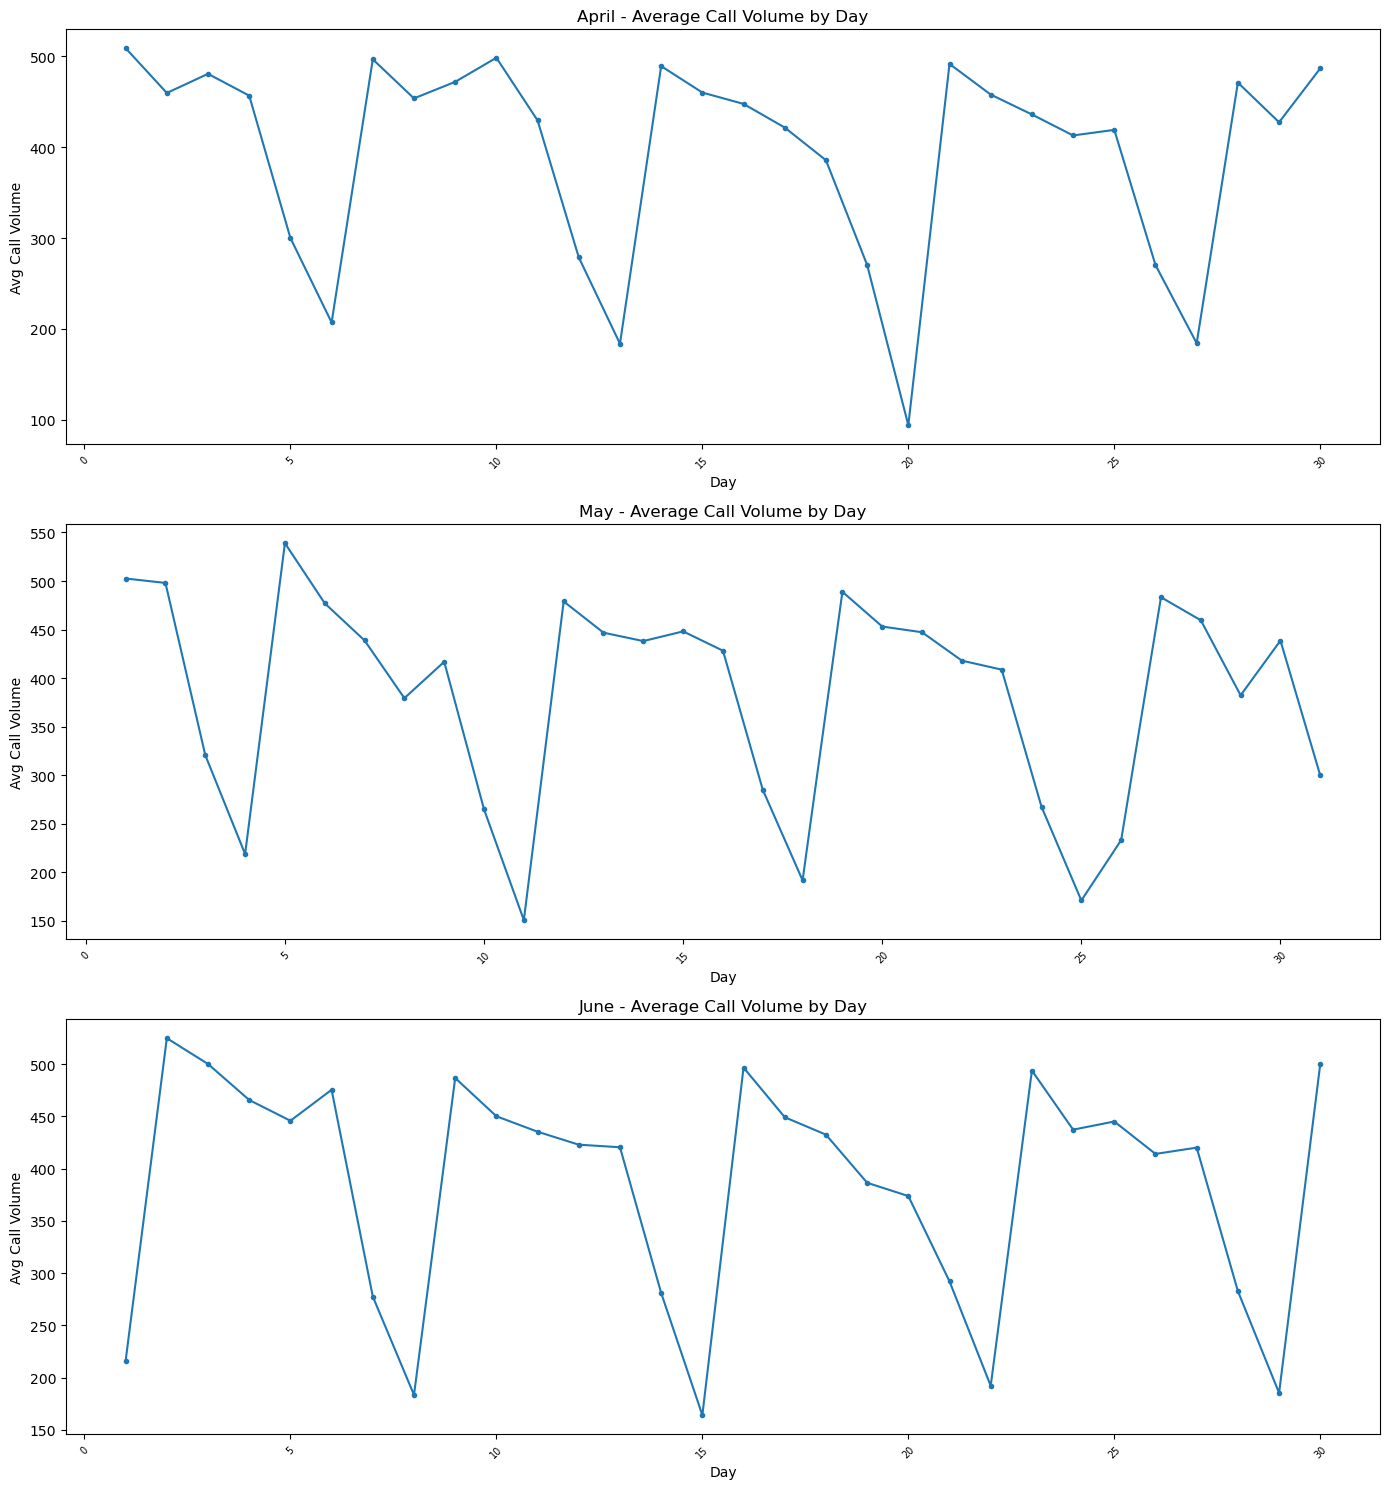

In [6]:
months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    interval_volume = df_month.groupby('Day')['Call Volume'].mean().reset_index()
    
    ax.plot(interval_volume['Day'], interval_volume['Call Volume'], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(f'{month} - Average Call Volume by Day')
    ax.set_xlabel('Day')
    ax.set_ylabel('Avg Call Volume')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

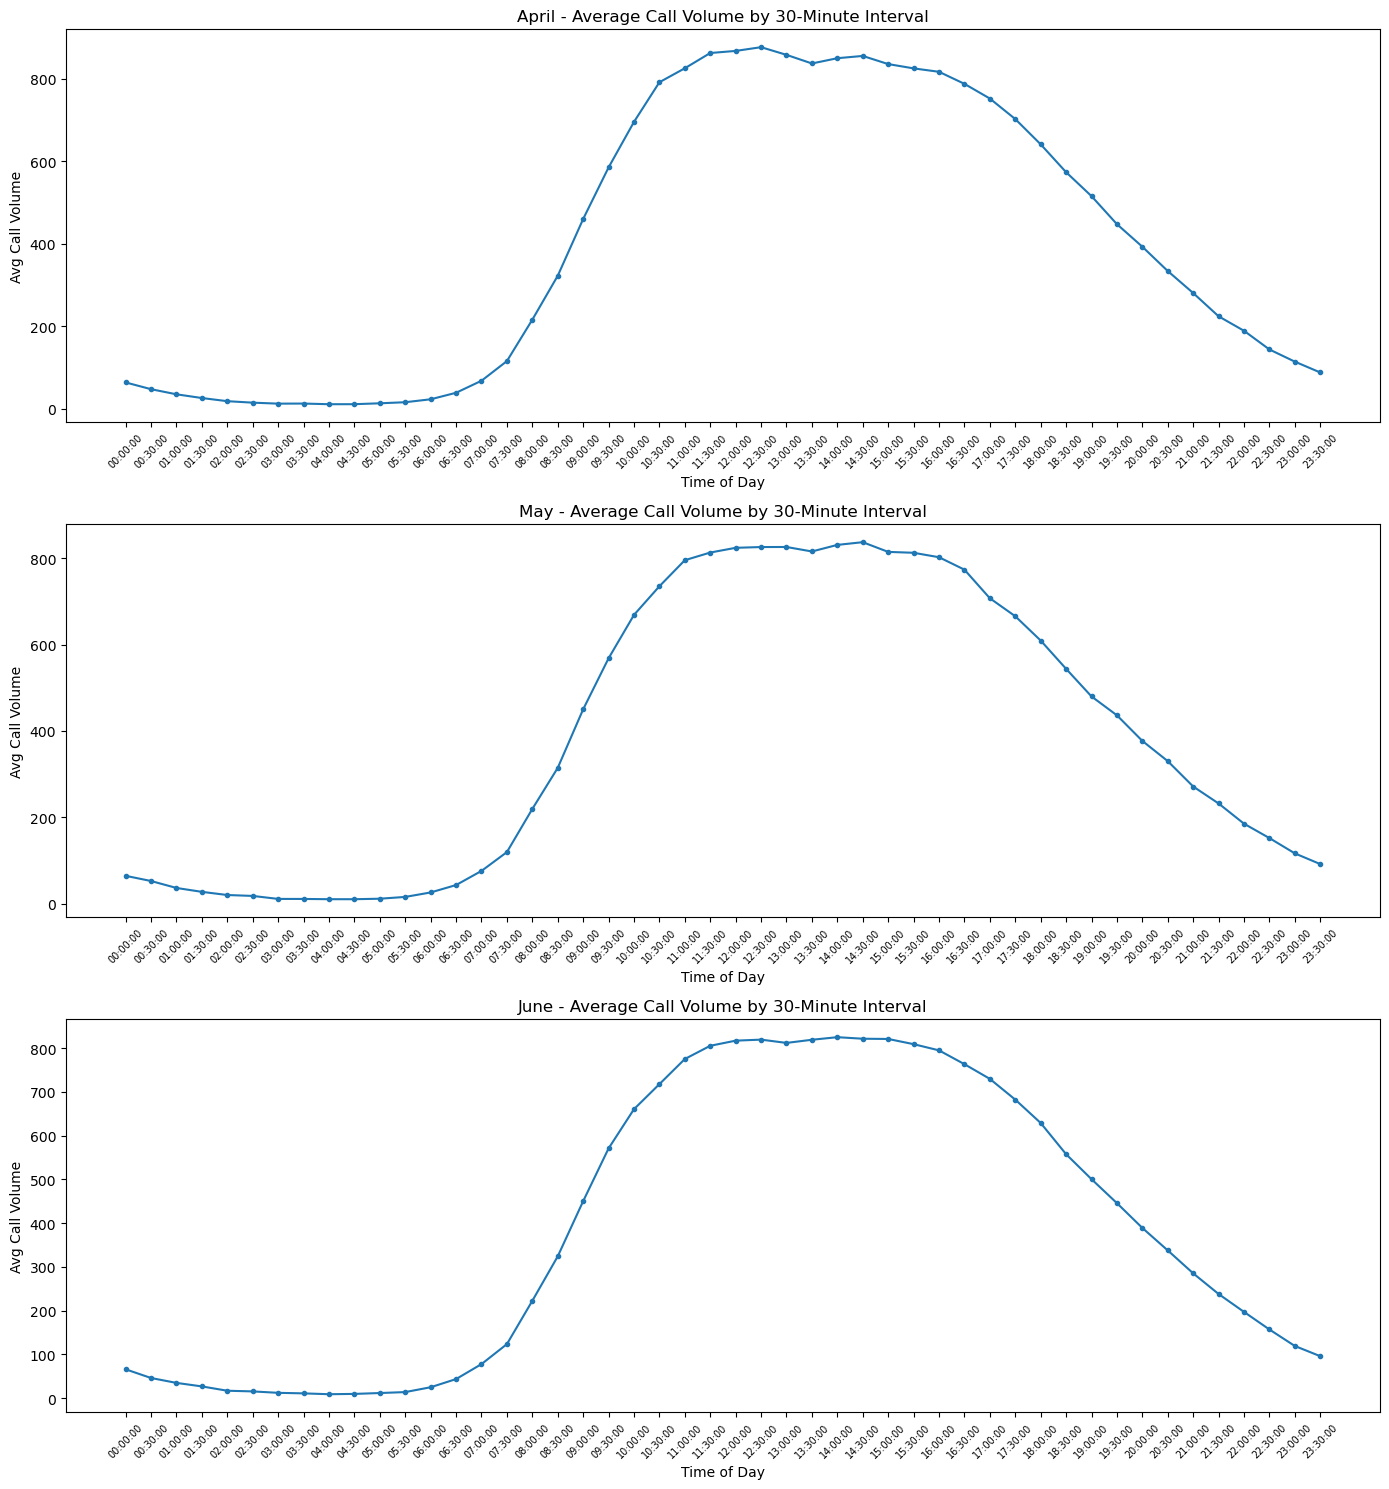

In [7]:
months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    interval_volume = df_month.groupby('Interval')['Call Volume'].mean().reset_index()
    
    ax.plot(interval_volume['Interval'], interval_volume['Call Volume'], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(f'{month} - Average Call Volume by 30-Minute Interval')
    ax.set_xlabel('Time of Day')
    ax.set_ylabel('Avg Call Volume')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

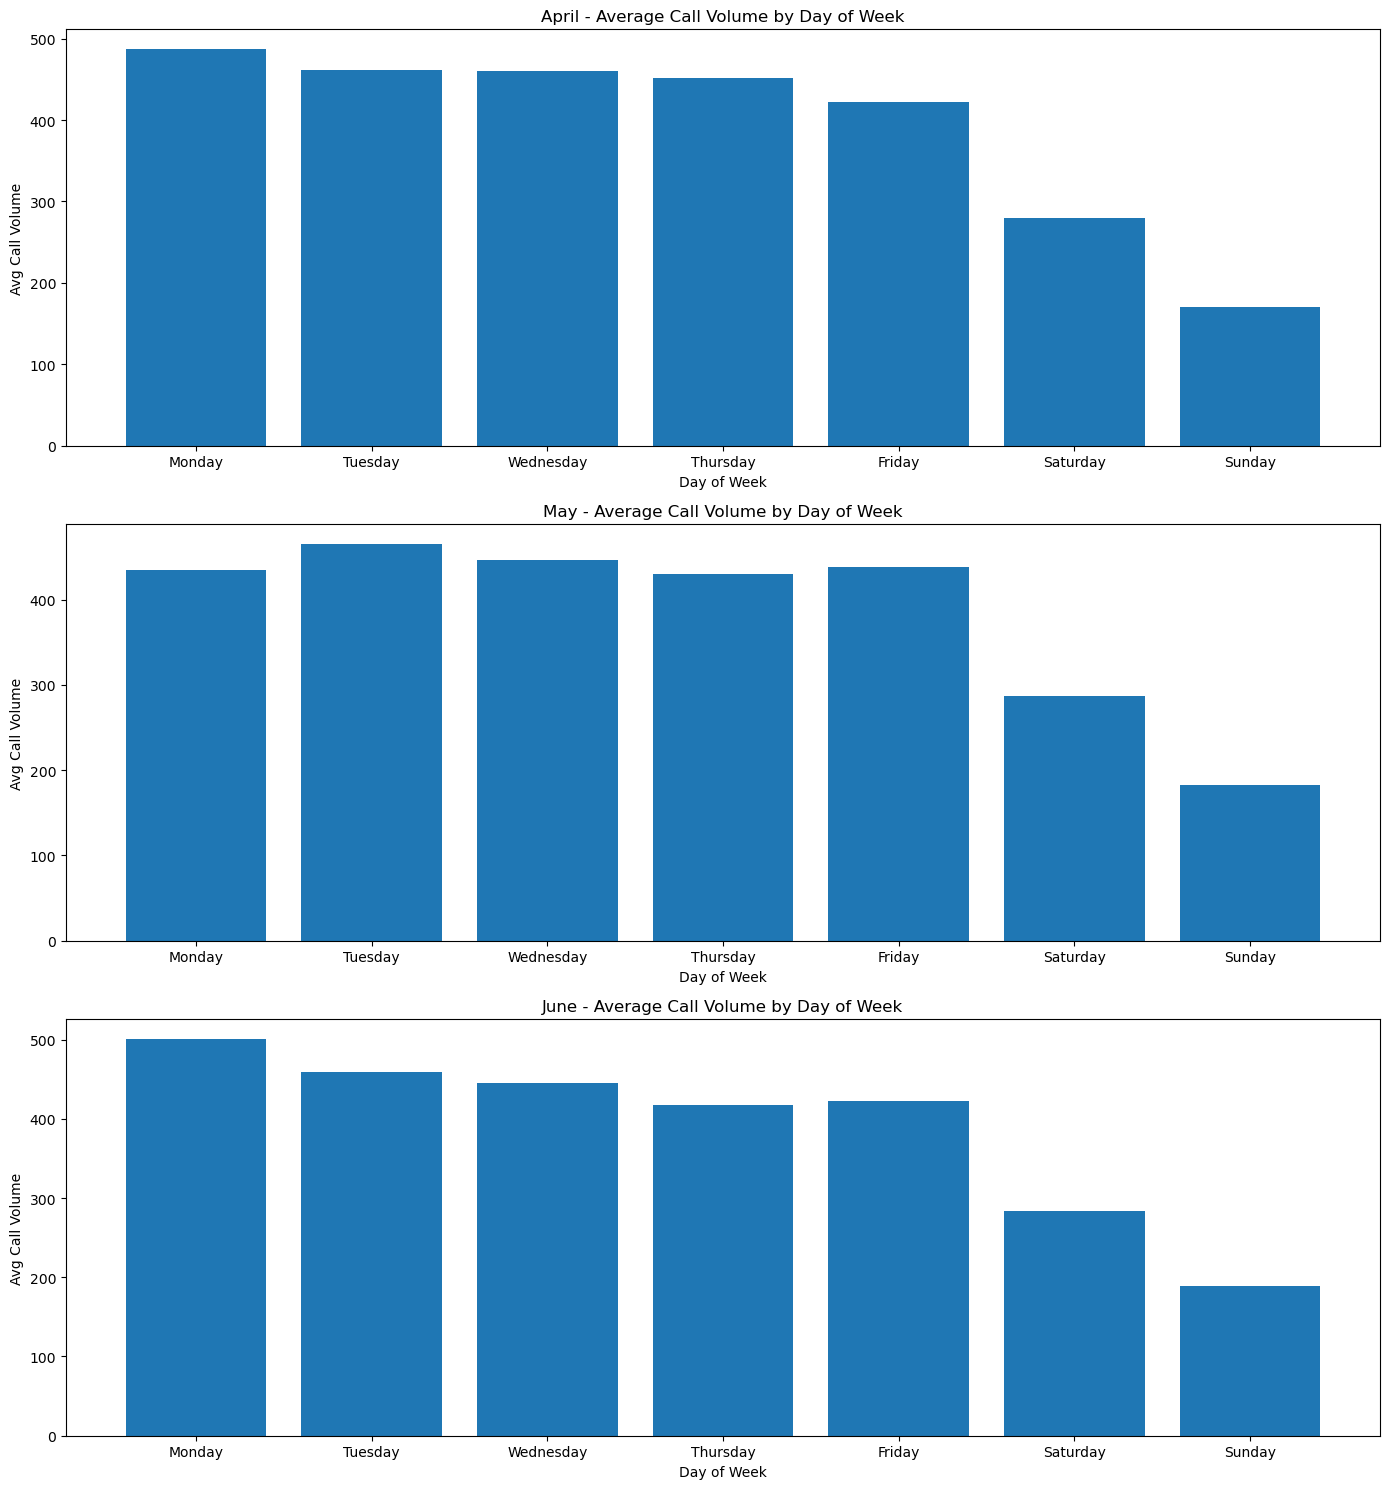

In [8]:
df_interval['Date'] = pd.to_datetime(df_interval['Month'] + ' ' + df_interval['Day'].astype(str) + ' 2025')
df_interval['DayOfWeek'] = df_interval['Date'].dt.day_name()

# Define order so it plots Mon -> Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    day_volume = df_month.groupby('DayOfWeek')['Call Volume'].mean().reindex(day_order)
    
    ax.bar(day_volume.index, day_volume.values)
    ax.set_title(f'{month} - Average Call Volume by Day of Week')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Avg Call Volume')

plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

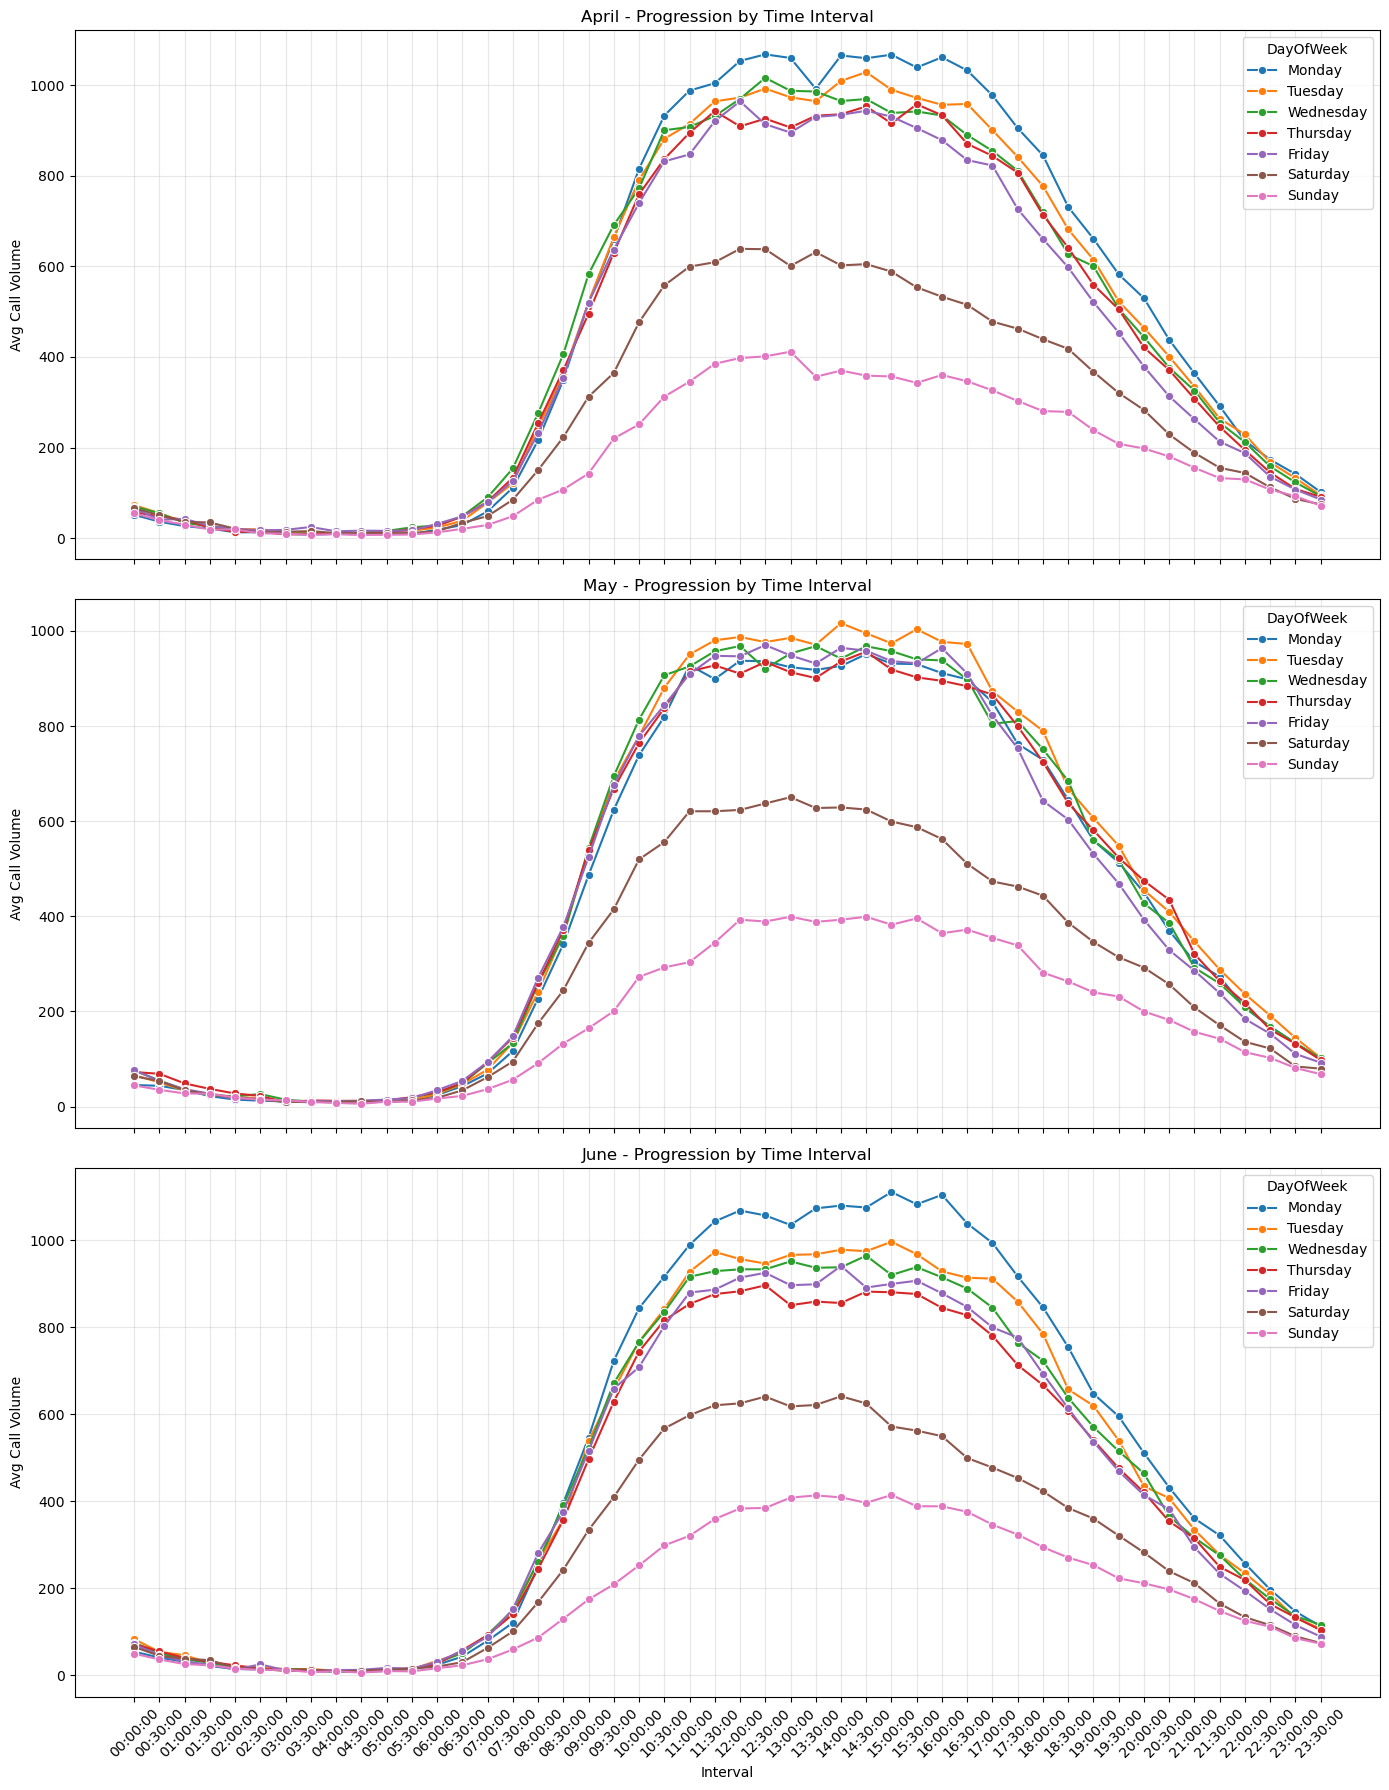

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ... (your existing date/day setup code) ...

# 1. Ensure Intervals are sorted chronologically
# If your interval column is a string, you might want to convert it to a sortable time
df_interval = df_interval.sort_values(by=['Date', 'Interval'])

months = ['April', 'May', 'June']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for ax, month in zip(axes, months):
    # Filter for the specific month
    df_month = df_interval[df_interval['Month'] == month]
    
    # 2. Group by Day and Interval to get the average for each specific time slot
    # This keeps the 'Interval' as a column for the X-axis
    interval_data = df_month.groupby(['DayOfWeek', 'Interval'])['Call Volume'].mean().reset_index()
    
    # 3. Use Seaborn to plot multiple lines (one per DayOfWeek)
    sns.lineplot(
        data=interval_data, 
        x='Interval', 
        y='Call Volume', 
        hue='DayOfWeek', 
        hue_order=day_order,
        ax=ax,
        marker='o' # Adds dots to each interval point
    )
    
    ax.set_title(f'{month} - Progression by Time Interval')
    ax.set_ylabel('Avg Call Volume')
    ax.grid(True, alpha=0.3)
    
    # Rotate x-labels if you have many intervals (like 15-min or 30-min)
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

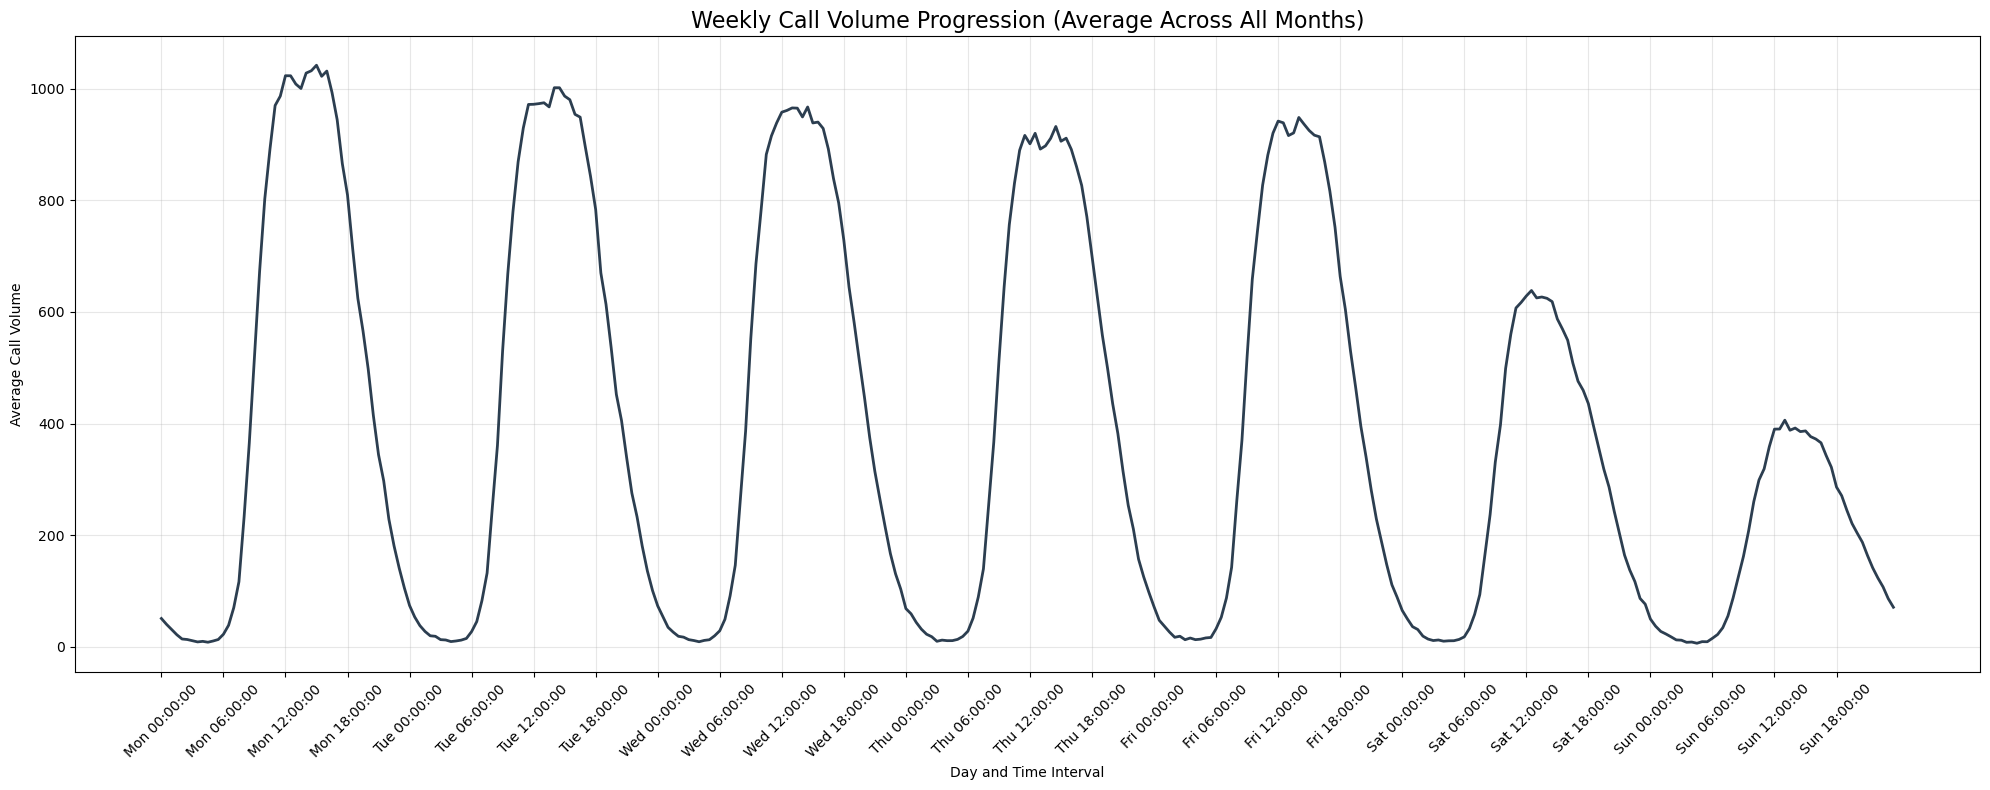

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a numeric mapping for sorting days correctly
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
df_interval['DayNum'] = df_interval['DayOfWeek'].map(day_map)

# 2. Aggregate across all months
# We group by DayNum (for sorting) and Interval to get the average volume
df_agg = df_interval.groupby(['DayNum', 'DayOfWeek', 'Interval'])['Call Volume'].mean().reset_index()

# 3. Sort by DayNum then Interval to ensure the line flows Mon -> Sun
df_agg = df_agg.sort_values(['DayNum', 'Interval'])

# 4. Create a label for the X-axis that combines Day and Time
df_agg['Timeline'] = df_agg['DayOfWeek'].str[:3] + " " + df_agg['Interval'].astype(str)

# Plotting
plt.figure(figsize=(20, 8))
sns.lineplot(data=df_agg, x='Timeline', y='Call Volume', sort=False, color='#2c3e50', linewidth=2)

# Cleanup X-Axis (Too many labels will overlap, so we show every Nth label)
ax = plt.gca()
ticks = ax.get_xticks()
labels = ax.get_xticklabels()
# Show a label every 12 intervals (e.g., every 6 hours if intervals are 30 mins)
plt.xticks(ticks[::12], [l.get_text() for l in labels[::12]], rotation=45)

plt.title('Weekly Call Volume Progression (Average Across All Months)', fontsize=16)
plt.xlabel('Day and Time Interval')
plt.ylabel('Average Call Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
from itertools import product

def load_and_clean_interval(filepath, portfolio_name):
    df = pd.read_csv(filepath)
    
    # ── 1. Standardize column names ──────────────────────────────────────────
    df.columns = df.columns.str.strip()
    
    # ── 2. Parse Service Level as float (may come in as "99.49%" or 0.9949) ──
    if df['Service Level'].dtype == object:
        df['Service Level'] = df['Service Level'].str.replace('%', '').astype(float) / 100
    
    # ── 3. Parse Abandoned Rate similarly ────────────────────────────────────
    if df['Abandoned Rate'].dtype == object:
        df['Abandoned Rate'] = df['Abandoned Rate'].str.replace('%', '').astype(float) / 100

    # ── 4. Build skeleton using ONLY valid days per month ────────────────────
    month_map = {
        'January':1,'February':2,'March':3,'April':4,
        'May':5,'June':6,'July':7,'August':8,
        'September':9,'October':10,'November':11,'December':12
    }

    all_intervals = [f"{h:02d}:{m:02d}:00" for h, m in product(range(24), [0, 30])]
    
    # Get actual (Month, Day) combos that exist in the data — avoids April 31 etc.
    valid_month_days = df[['Month', 'Day']].drop_duplicates()

    skeleton = pd.DataFrame(
        [(row.Month, row.Day, interval)
         for _, row in valid_month_days.iterrows()
         for interval in all_intervals],
        columns=['Month', 'Day', 'Interval']
    )

    df = skeleton.merge(df, on=['Month', 'Day', 'Interval'], how='left')
    
    # ── 5. Add date + time features ──────────────────────────────────────────
    df['Month_Num'] = df['Month'].map(month_map)
    df['Date']      = pd.to_datetime(
        df['Month_Num'].astype(str) + '-' + df['Day'].astype(str) + '-2024',
        format='%m-%d-%Y'
    )
    df['DayOfWeek']   = df['Date'].dt.day_name()
    df['DayOfWeek_N'] = df['Date'].dt.dayofweek        # 0=Mon, 6=Sun
    df['WeekOfMonth'] = (df['Day'] - 1) // 7 + 1
    df['IntervalIdx'] = df['Interval'].apply(
        lambda x: int(x.split(':')[0]) * 2 + int(x.split(':')[1]) // 30
    )  # 0–47
    df['Hour']       = df['Interval'].apply(lambda x: int(x.split(':')[0]))
    df['Is_Weekend'] = df['DayOfWeek_N'].isin([5, 6]).astype(int)
    df['Portfolio']  = portfolio_name

    # ── 6. Smart missing value imputation ────────────────────────────────────
    df = df.sort_values(['Month', 'Day', 'IntervalIdx']).reset_index(drop=True)

    # Overnight slots (midnight–4am): zero-fill call volume
    overnight_mask = df['IntervalIdx'].between(0, 7)
    df.loc[overnight_mask & df['Call Volume'].isna(), 'Call Volume'] = 0

    # Linear interpolation within each day, then fill edges
    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = (
            df.groupby(['Month', 'Day'])[col]
              .transform(lambda x: x.interpolate(method='linear').bfill().ffill())
        )

    # Fallback: same weekday + same interval median
    for col in ['CCT', 'Call Volume', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = df.groupby(['DayOfWeek_N', 'IntervalIdx'])[col]\
                    .transform(lambda x: x.fillna(x.median()))

    # ── 7. Enforce non-negativity & valid ranges ──────────────────────────────
    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate']:
        df[col] = df[col].clip(lower=0)
    df['Abandoned Rate'] = df['Abandoned Rate'].clip(0, 1)

    # ── 8. Round volume & abandoned calls to integers ─────────────────────────
    df['Call Volume']     = df['Call Volume'].round().astype(int)
    df['Abandoned Calls'] = df['Abandoned Calls'].round().astype(int)

    return df


# ── Load all 4 portfolios ─────────────────────────────────────────────────────
portfolios = {
    'A': './data/A - Interval.csv',
    'C': './data/C - Interval.csv',
}

cleaned = {}
for name, path in portfolios.items():
    cleaned[name] = load_and_clean_interval(path, name)
    print(f"Portfolio {name}: {len(cleaned[name])} rows, "
          f"{cleaned[name].isna().sum().sum()} NaNs remaining")

df_all = pd.concat(cleaned.values(), ignore_index=True)
print(f"\nMaster dataframe: {df_all.shape}")


Portfolio A: 4368 rows, 292 NaNs remaining
Portfolio C: 4368 rows, 9 NaNs remaining

Master dataframe: (8736, 18)


In [13]:
import pandas as pd

df_interval = pd.read_csv('./data/A - Interval.csv', index_col=0)


# 1. Define the start and end of the period
# April 1st, 2025 at 00:00 to June 30th, 2025 at 23:30
start = '2025-04-01 00:00:00'
end = '2025-06-30 23:30:00'

# 2. Generate the date range with 30-minute frequency
# 30min or 30T is the frequency for 30-minute increments
dr = pd.date_range(start=start, end=end, freq='30min')

# 3. Create the DataFrame and extract the requested columns
df = pd.DataFrame({'Timestamp': dr})

df_intervals = pd.DataFrame({
    'Month': df['Timestamp'].dt.month_name(),
    'Day': df['Timestamp'].dt.day,
    'Interval': df['Timestamp'].dt.strftime('%H:%M:%S'),
    'Day of the Week': df['Timestamp'].dt.day_name()
})

df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
df['Call Volume'] = df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
df['Service Level'] = df['Service Level'].interpolate(method='polynomial', order=1)
df['Abandoned Rate'] = df['Abandoned Rate'].interpolate(method='linear')
df['CCT'] = df['CCT'].interpolate(method='polynomial', order=2)
mask = df['Abandoned Calls'].isna()
df.loc[mask, 'Abandoned Calls'] = (df.loc[mask, 'Abandoned Rate'] * df.loc[mask, 'Call Volume']).astype(int)

In [14]:
month_map = {
        'January':1,'February':2,'March':3,'April':4,
        'May':5,'June':6,'July':7,'August':8,
        'September':9,'October':10,'November':11,'December':12
    }

In [15]:
df.head(80)

,Month,Day,Interval,Day of the Week,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,April,1,00:00:00,Tuesday,1.0000,5,0.0,0.0000,137.60
1,April,1,00:30:00,Tuesday,1.0000,5,0.0,0.0000,263.40
2,April,1,01:00:00,Tuesday,1.0000,4,0.0,0.0000,333.25
3,April,1,01:30:00,Tuesday,1.0000,3,0.0,0.0000,170.00
4,April,1,02:00:00,Tuesday,1.0000,1,0.0,0.0000,667.00
...,...,...,...,...,...,...,...,...,...
75,April,2,13:30:00,Wednesday,0.9634,273,0.0,0.0000,304.00
76,April,2,14:00:00,Wednesday,0.9964,275,0.0,0.0000,339.43
77,April,2,14:30:00,Wednesday,0.9960,253,0.0,0.0000,292.37
78,April,2,15:00:00,Wednesday,0.9515,268,0.0,0.0000,351.72


In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd

import datetime

In [17]:
df_daily = pd.read_csv('./data/C - Daily.csv', index_col=0)

In [18]:
df_daily['Call Volume'] = df_daily['Call Volume'].interpolate(method='linear').astype(int)
df_daily['Service Level'] = df_daily['Service Level'].interpolate(method='linear')
df_daily['Abandon Rate'] = df_daily['Abandon Rate'].interpolate(method='linear')
df_daily['CCT'] = df_daily['CCT'].interpolate(method='linear')
df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily.head()

/tmp/ipykernel_301331/1511036297.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_daily['Date'] = pd.to_datetime(df_daily['Date'])


,Date,Call Volume,CCT,Service Level,Abandon Rate
0,2024-01-01,8059,333.48,0.9984,0.0014
1,2024-01-02,30738,370.36,0.5464,0.1005
2,2024-01-03,29358,369.60,0.5153,0.0738
3,2024-01-04,27542,372.00,0.6336,0.0451
4,2024-01-05,25956,375.03,0.7092,0.0273


In [19]:
df_daily.nlargest(columns='Abandon Rate', n=5)

,Date,Call Volume,CCT,Service Level,Abandon Rate
641,2025-10-03,22658,361.77,0.3132,0.2209
648,2025-10-10,19888,358.31,0.6042,0.1520
642,2025-10-04,14077,357.81,0.4658,0.1272
1,2024-01-02,30738,370.36,0.5464,0.1005
64,2024-03-05,26921,368.85,0.4338,0.0870


In [20]:
staffing = pd.read_csv('./data/Daily Staffing.csv', index_col=0)
staffing = staffing[['Unnamed: 0', 'C']]
staffing.columns = ['Date', 'C']
staffing['Date'] = pd.to_datetime(staffing['Date'])
staffing.head()

,Date,C
0,2025-01-01,353.0
1,2025-01-02,491.0
2,2025-01-03,462.0
3,2025-01-04,352.0
4,2025-01-05,224.0


In [21]:
df = df_daily.merge(staffing, on='Date', how='inner')
df.head()

,Date,Call Volume,CCT,Service Level,Abandon Rate,C
0,2025-01-01,8051,311.42,0.9770,0.0051,353.0
1,2025-01-02,26094,343.18,0.9414,0.0064,491.0
2,2025-01-03,25315,327.78,0.9570,0.0051,462.0
3,2025-01-04,16723,317.20,0.8545,0.0152,352.0
4,2025-01-05,9615,364.23,0.6499,0.0230,224.0


In [22]:
df.corr()

,Date,Call Volume,CCT,Service Level,Abandon Rate,C
Date,1.000000,-0.023540,0.152894,0.091635,0.074920,-0.372472
Call Volume,-0.023540,1.000000,0.068105,-0.016640,0.025307,0.823760
CCT,0.152894,0.068105,1.000000,-0.275289,0.165274,-0.064430
Service Level,0.091635,-0.016640,-0.275289,1.000000,-0.783292,-0.002393
Abandon Rate,0.074920,0.025307,0.165274,-0.783292,1.000000,-0.047266
C,-0.372472,0.823760,-0.064430,-0.002393,-0.047266,1.000000


In [23]:
from export_to_template import fill_template

forecast_c['Portfolio'] = 'C'

august_intervals = forecast_c.rename(columns={
    'Calls_Offered_C':   'Call_Volume',
    'Abandoned_Calls_C': 'Abandoned_Calls',
    'Abandoned_Rate_C':  'Abandoned_Rate',
    'CCT_C':             'CCT'
})

output_df = fill_template(
    august_intervals,
    template_path='./template_forecast_v00.csv',
    output_path='./August_2026_Forecast_v00.csv'
)

NameError: name 'forecast_c' is not defined